# Laboratorio #5 — Agentes en el Arcade Learning Environment (ALE): Space Invaders

**CC3092 Deep Learning y Sistemas Inteligentes**

En este laboratorio **no se entrena ningún agente**. El objetivo es dejar funcionando la
infraestructura que permite que un agente (aleatorio o de regla simple) interactúe con un
entorno de Atari a través de ALE, y que esa interacción se grabe en video. Ese mismo
código es la base para entrenar agentes en proyectos futuros.

Las reglas de tecnología permitida/prohibida para este lab están en
[`CLAUDE.md`](CLAUDE.md).

## 1. El Arcade Learning Environment (ALE)

**Referencias:** Bellemare et al. (2013), *The Arcade Learning Environment: An Evaluation
Platform for General Agents*, JAIR 47:253-279 · Machado et al. (2018), *Revisiting the ALE*,
JAIR 61:523-562 · [docs de ale-py](https://ale.farama.org/).

### ¿Qué es ALE y qué problema resuelve?

ALE es una plataforma que expone los juegos de **Atari 2600** como entornos de aprendizaje
por refuerzo. El problema que resuelve es de **evaluación**: antes de ALE cada investigador
probaba su algoritmo en un dominio hecho a medida, así que los resultados no eran
comparables. ALE ofrece >100 juegos distintos que comparten exactamente la misma interfaz
(una imagen de 210x160 y un puñado de acciones de joystick), diseñados por terceros y no por
investigadores de IA, lo que evita sesgar el benchmark hacia un algoritmo concreto.

**Relación con Stella:** ALE no emula nada por sí mismo. Es una capa construida sobre
**Stella**, un emulador de Atari 2600 de código abierto. Stella ejecuta la ROM original del
juego; ALE se conecta a él para (1) leer la pantalla y los 128 bytes de RAM, (2) inyectar
acciones de joystick, y (3) leer del estado interno el *score* y las vidas, que traduce a la
señal de recompensa. Los juegos son las **ROMs originales sin modificar** — desde `ale-py`
0.10 vienen incluidas en el paquete, ya no hace falta `AutoROM`.

In [1]:
import ale_utils          # hace gym.register_envs(ale_py) al importarse
import gymnasium as gym
import ale_py

print("gymnasium:", gym.__version__, "| ale-py:", ale_py.__version__)

gymnasium: 1.3.0 | ale-py: 0.12.1


### Variantes del mismo juego

Un mismo juego aparece en ALE bajo varios IDs y parámetros. Las diferencias importan porque
cambian la dificultad y la comparabilidad de los resultados.

| Variante | `frameskip` | `repeat_action_probability` | Notas |
|---|---|---|---|
| `SpaceInvaders-v0` | `(2,5)` aleatorio | 0.25 | legacy |
| `SpaceInvaders-v4` | `(2,5)` aleatorio | 0.0 | legacy, determinista |
| `SpaceInvadersNoFrameskip-v4` | 1 | 0.0 | el usado en el paper de DQN, con wrappers propios |
| `ALE/SpaceInvaders-v5` | 4 | 0.25 | **recomendado**, sigue Machado et al. (2018) |

- **`-ram`**: no es un ID en `ale-py` 0.12 sino el argumento `obs_type="ram"`, que devuelve
  los 128 bytes de RAM en vez de la imagen. También existe `obs_type="grayscale"`.
- **`frameskip`**: número de frames que se repite cada acción (ver abajo).
- **`repeat_action_probability`** (*sticky actions*): con probabilidad 0.25 el emulador
  **ignora** la acción nueva y repite la anterior. Es la forma que propone Machado et al. de
  inyectar estocasticidad: sin ella, un agente puede memorizar una secuencia fija de acciones
  y obtener un score altísimo sin haber aprendido nada (*the trajectory optimization problem*).
- **`full_action_space`**: si es `True` expone las 18 acciones del joystick de Atari para
  **todos** los juegos, aunque el juego use menos. Sirve para entrenar un solo agente sobre
  muchos juegos a la vez; si es `False` (default) se expone sólo el subconjunto mínimo.

In [2]:
print("spec por defecto:", ale_utils.crear_entorno("ALE/SpaceInvaders-v5").spec.kwargs)

spec por defecto: {'game': 'space_invaders', 'repeat_action_probability': 0.25, 'full_action_space': False, 'frameskip': 4, 'max_num_frames_per_episode': 108000, 'render_mode': 'rgb_array'}


A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


### Frame skipping

Con `frameskip=k`, cada llamada a `step()` repite la misma acción durante **k frames** del
emulador y devuelve sólo el último (o el máximo pixel a pixel de los dos últimos, para evitar
el parpadeo de sprites del hardware de Atari). La recompensa que se devuelve es la **suma**
de los k frames.

Por qué importa:

- **Velocidad de simulación:** con `k=4` el agente decide 4 veces menos y el emulador corre
  ~4x más episodios por segundo de cómputo. Como el agente es la parte cara (una CNN), es la
  mayor ganancia de rendimiento del pipeline.
- **Aprendizaje:** dos frames consecutivos de Atari a 60 Hz son casi idénticos, así que
  decidir en cada uno es información redundante. Saltar frames acorta el horizonte efectivo
  del episodio (menos pasos entre la acción y su consecuencia), lo que facilita la asignación
  de crédito. El precio es la granularidad: con un `k` muy alto el agente pierde la capacidad
  de reaccionar a eventos rápidos.

### Space Invaders: mecánica y recompensa

El jugador controla un cañón que se mueve horizontalmente en la base de la pantalla y
dispara hacia arriba. Una formación de alienígenas desciende disparando; hay escudos
destructibles y una nave nodriza que cruza por arriba y vale más puntos. El objetivo es
destruir la formación antes de que llegue abajo. Se pierde una de las 3 vidas al ser
alcanzado, y el episodio termina al perder la última.

**Score → recompensa:** ALE lee el score del juego directamente de la RAM y define la
recompensa de cada paso como el **incremento de score** ocurrido durante ese paso
(`r_t = score_t − score_{t−1}`). Es decir, la recompensa es 0 en la mayoría de los pasos y
positiva sólo cuando se destruye un alienígena (10-30 puntos según la fila) o la nave
nodriza (50-200). El retorno de un episodio es entonces igual al score final del juego. Es
una señal **dispersa** (*sparse*) y nunca negativa: perder una vida no resta puntos, sólo
acorta el episodio.

## 2. Espacios de observación y acción

Todo lo que se afirma aquí se verifica en vivo contra el entorno.

In [3]:
env = ale_utils.crear_entorno("ALE/SpaceInvaders-v5")
print("observation_space:", env.observation_space)
print("action_space     :", env.action_space)
print("acciones         :", env.unwrapped.get_action_meanings())

obs, info = env.reset(seed=0)
print("obs shape/dtype  :", obs.shape, obs.dtype, "| bytes:", obs.nbytes)
print("info             :", info)
env.close()

observation_space: Box(0, 255, (210, 160, 3), uint8)
action_space     : Discrete(6)
acciones         : ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
obs shape/dtype  : (210, 160, 3) uint8 | bytes: 100800
info             : {'lives': 3, 'episode_frame_number': 0, 'frame_number': 0, 'seeds': (np.uint32(2968811710), np.uint32(3677149159))}


### Observación por defecto vs. CartPole-v1

| | `ALE/SpaceInvaders-v5` | `CartPole-v1` (Lab #4) |
|---|---|---|
| Espacio | `Box(0, 255, (210,160,3), uint8)` | `Box(4,)` de `float32` |
| Qué es | la pantalla RGB cruda | `[x, ẋ, θ, θ̇]`, el estado físico |
| Tamaño | 100 800 valores | 4 valores |
| Semántica | ninguna: hay que **extraerla** | directa, cada componente tiene significado |

Implicaciones de trabajar con imágenes en vez de vectores de baja dimensión:

1. **Se necesita una CNN.** Un MLP sobre 100 800 entradas es inviable; hace falta una red
   convolucional que aprenda a detectar sprites. El agente ya no es sólo un problema de
   control, sino también de visión.
2. **Observación ≠ estado (POMDP).** Un frame estático no dice hacia dónde se mueve un
   alienígena ni una bala. El proceso deja de ser un MDP sobre la observación; la solución
   estándar es apilar frames (ver `FrameStackObservation`).
3. **Costo de memoria.** Un replay buffer de 1M de transiciones a 100 KB cada una serían
   ~200 GB. De ahí que el preprocesamiento estándar (gris + 84x84 + `uint8`) reduzca cada
   frame a 7 KB, y que se guarden frames individuales en vez de stacks completos.
4. **Escala.** Los valores son `uint8` en [0,255]; hay que normalizarlos antes de entrar a la
   red.

In [4]:
for tipo in ["rgb", "ram", "grayscale"]:
    e = ale_utils.crear_entorno("ALE/SpaceInvaders-v5", obs_type=tipo)
    print(f'obs_type="{tipo}":', e.observation_space)
    e.close()

obs_type="rgb": Box(0, 255, (210, 160, 3), uint8)
obs_type="ram": Box(0, 255, (128,), uint8)
obs_type="grayscale": Box(0, 255, (210, 160), uint8)


### Observación en RAM (`obs_type="ram"`)

Devuelve `Box(0, 255, (128,), uint8)`: los **128 bytes** de memoria de la consola Atari 2600.
Ahí viven directamente la posición del cañón, la de cada alienígena, el score y las vidas.

Cuándo preferirla sobre la imagen:

- Cuando interesa el problema de **control** y no el de visión: se evita entrenar una CNN, y
  un MLP pequeño basta. Los experimentos corren en minutos en vez de días.
- Como **límite superior** de referencia: mide qué tan bien se puede hacer con el estado casi
  completo, para saber cuánto pierde el agente basado en píxeles.
- Cuando hay poco cómputo o poca memoria (128 bytes vs 100 KB por observación).

Sus límites: la codificación es opaca y distinta en cada juego (el byte 17 significa algo
distinto en cada ROM), así que un agente entrenado en RAM no transfiere entre juegos, y
tampoco es comparable con la literatura, que reporta resultados sobre píxeles.

### Espacio de acción

`Discrete(6)` — el subconjunto mínimo que Space Invaders realmente usa:

| Índice | Acción | Efecto |
|---|---|---|
| 0 | `NOOP` | no hacer nada; el cañón se queda donde está |
| 1 | `FIRE` | disparar sin moverse |
| 2 | `RIGHT` | mover a la derecha sin disparar |
| 3 | `LEFT` | mover a la izquierda sin disparar |
| 4 | `RIGHTFIRE` | mover a la derecha **y** disparar |
| 5 | `LEFTFIRE` | mover a la izquierda **y** disparar |

Son combinaciones del joystick: dirección × botón. Las acciones compuestas (4 y 5) existen
porque el hardware permitía empujar la palanca y pulsar el botón a la vez, y son las útiles
en la práctica: esquivar sin dejar de disparar. Con `full_action_space=True` el espacio pasa
a `Discrete(18)` (las 18 combinaciones posibles del joystick, incluidas las que este juego
ignora), lo que permite usar una misma cabeza de salida para todos los juegos de ALE.

In [5]:
e = ale_utils.crear_entorno("ALE/SpaceInvaders-v5", full_action_space=True)
print("full_action_space=True ->", e.action_space)
e.close()

full_action_space=True -> Discrete(18)


### `AtariPreprocessing` y `FrameStackObservation`

**`AtariPreprocessing`** es el wrapper de Gymnasium que reproduce el preprocesamiento
estándar del paper de DQN (Mnih et al., 2015). Aplica típicamente:

| Transformación | Para qué |
|---|---|
| escala de grises | el color no aporta información en Atari; 3 canales → 1 |
| redimensionado a 84x84 | reduce 100 800 → 7 056 valores por frame |
| *frame skipping* (`frame_skip=4`) con max-pooling de los 2 últimos frames | velocidad, y elimina el parpadeo de sprites del hardware |
| `noop_max=30` | ejecuta un número aleatorio de `NOOP` al inicio, para que los episodios no arranquen siempre igual |
| `terminal_on_life_loss` | tratar cada vida como un episodio, señal de fracaso más inmediata |
| `scale_obs` | pasa a `float32` en [0,1] (opcional: gastar 4x memoria en el buffer) |
| recorte de recompensa a {−1, 0, +1} | permite usar los mismos hiperparámetros en juegos cuyos scores viven en escalas muy distintas |

**`FrameStackObservation`** (antes `FrameStack`) apila las últimas `k` observaciones
(típicamente 4) en un solo tensor `(4, 84, 84)`. Se usa junto con `AtariPreprocessing` porque
resuelve exactamente el problema 2 de la sección anterior: un frame no contiene velocidad ni
dirección. Con 4 frames consecutivos la red puede inferir hacia dónde va cada objeto, y la
observación vuelve a aproximar un estado markoviano. El orden importa: primero se preprocesa
(gris + resize), después se apila, para no apilar imágenes de 100 KB.

> En este laboratorio **no se aplican** estos wrappers: el agente no aprende, así que no hay
> nada que preprocesar, y el video debe grabarse con la imagen original. Se documentan
> porque son el siguiente paso al entrenar.

## 3. Módulo de desarrollo: `ale_utils.py`

Módulo de funciones reutilizables para crear entornos, ejecutar agentes y grabar video. El
notebook lo **importa**; no redefine nada. Las firmas son las que pide el enunciado.

| Función | Qué hace |
|---|---|
| `crear_entorno(nombre_entorno, video_folder=None, episode_trigger=None, ...)` | crea el entorno y, si se da `video_folder`, lo envuelve con `RecordVideo` |
| `agente_aleatorio(observation, env)` | baseline: `env.action_space.sample()` |
| `agente_regla_simple(observation, env)` | política fija no aprendida |
| `ejecutar_episodio(env, funcion_agente, max_steps=10000)` | corre un episodio; retorna `(pasos, recompensa_total)` |
| `generar_video_agente(nombre_entorno, funcion_agente, video_folder, name_prefix, n_episodios=1)` | combina las anteriores y cierra el entorno |

Dos detalles que no son opcionales:

- `gym.register_envs(ale_py)` se ejecuta al importar el módulo. Desde `ale-py` 0.10, sin esa
  llamada `gym.make("ALE/SpaceInvaders-v5")` lanza `NameNotFound`.
- `generar_video_agente` llama a **`env.close()`** en un `finally`. `RecordVideo` escribe el
  archivo al cerrar el entorno: sin `close()` el último `.mp4` queda incompleto o vacío.

In [6]:
import inspect
print(inspect.getsource(ale_utils.crear_entorno))

def crear_entorno(nombre_entorno, video_folder=None, episode_trigger=None,
                  name_prefix="rl-video", render_mode="rgb_array", **kwargs):
    """Crea un entorno de Gymnasium, opcionalmente envuelto para grabar video.

    video_folder    carpeta destino de los .mp4; si es None no se graba.
    episode_trigger funcion ep_idx -> bool; por defecto graba todos los episodios.
    render_mode     "rgb_array" es indispensable para que RecordVideo tenga frames.
    kwargs          se pasan tal cual a gym.make (obs_type, frameskip,
                    repeat_action_probability, full_action_space, ...).
    """
    env = gym.make(nombre_entorno, render_mode=render_mode, **kwargs)
    if video_folder is not None:
        Path(video_folder).mkdir(parents=True, exist_ok=True)
        env = gym.wrappers.RecordVideo(
            env,
            video_folder=str(video_folder),
            episode_trigger=episode_trigger or (lambda ep: True),
            name_prefix=name_prefix,
       

### 3.1. Genericidad: las mismas funciones sobre un entorno no-Atari

`crear_entorno` y `ejecutar_episodio` no saben nada de Atari. Sobre `CartPole-v1` (Lab #4)
funcionan igual.

In [7]:
cartpole = ale_utils.crear_entorno("CartPole-v1")
pasos, retorno = ale_utils.ejecutar_episodio(cartpole, ale_utils.agente_aleatorio, seed=0)
cartpole.close()
print(f"CartPole-v1, agente aleatorio -> {pasos} pasos, retorno {retorno}")

CartPole-v1, agente aleatorio -> 18 pasos, retorno 18.0


### 3.2. Video del agente aleatorio en `ALE/SpaceInvaders-v5`

Entregable principal: al menos un episodio completo grabado.

In [8]:
rutas_rand, met_rand = ale_utils.generar_video_agente(
    "ALE/SpaceInvaders-v5", ale_utils.agente_aleatorio,
    video_folder="videos", name_prefix="spaceinvaders_random",
    n_episodios=1, seed=0)

for ruta, (pasos, recompensa) in zip(rutas_rand, met_rand):
    print(f"{ruta}\n  pasos sobrevividos: {pasos}\n  recompensa total  : {recompensa}")

videos/spaceinvaders_random-episode-0.mp4
  pasos sobrevividos: 298
  recompensa total  : 35.0


/Users/nesstor/Documents/git_u/2026/deepLearning/.venv/lib/python3.14/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Users/nesstor/Documents/git_u/2026/deepLearning/projects/space_invaders/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


### 3.3. El agente de regla simple

Política fija, **sin aprendizaje**: barre de lado a lado disparando continuamente,
alternando `RIGHTFIRE` y `LEFTFIRE` cada 20 pasos. La hipótesis es que cubrir el ancho de la
pantalla mientras se dispara siempre debería acertar más que moverse al azar — el agente
aleatorio gasta 4 de cada 6 acciones sin disparar.

Es una regla sobre el contador de pasos, no sobre la observación: no mira la pantalla, así
que no esquiva nada.

In [9]:
print(inspect.getsource(ale_utils.agente_regla_simple))

def agente_regla_simple(observation, env):
    """Politica fija, sin aprendizaje: barre de lado a lado disparando.

    Alterna RIGHTFIRE/LEFTFIRE cada PASOS_POR_TRAMO pasos para cubrir el ancho de la
    pantalla mientras dispara de forma continua, en vez de moverse al azar. No mira la
    observacion: es una regla sobre el contador de pasos, no una politica aprendida.
    Si el entorno no tiene las 6 acciones de Space Invaders, cae al agente aleatorio.
    """
    acciones = getattr(env.unwrapped, "get_action_meanings", lambda: [])()
    if "RIGHTFIRE" not in acciones or "LEFTFIRE" not in acciones:
        return agente_aleatorio(observation, env)

    PASOS_POR_TRAMO = 20
    agente_regla_simple.t += 1
    hacia_la_derecha = (agente_regla_simple.t // PASOS_POR_TRAMO) % 2 == 0
    return acciones.index("RIGHTFIRE" if hacia_la_derecha else "LEFTFIRE")



In [10]:
rutas_regla, met_regla = ale_utils.generar_video_agente(
    "ALE/SpaceInvaders-v5", ale_utils.agente_regla_simple,
    video_folder="videos", name_prefix="spaceinvaders_regla",
    n_episodios=1, seed=0)

for ruta, (pasos, recompensa) in zip(rutas_regla, met_regla):
    print(f"{ruta}\n  pasos sobrevividos: {pasos}\n  recompensa total  : {recompensa}")

/Users/nesstor/Documents/git_u/2026/deepLearning/.venv/lib/python3.14/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Users/nesstor/Documents/git_u/2026/deepLearning/projects/space_invaders/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


videos/spaceinvaders_regla-episode-0.mp4
  pasos sobrevividos: 405
  recompensa total  : 130.0


### 3.4. Comparación sobre 10 episodios

Un episodio no dice nada: la varianza en Atari es enorme. Se corren 10 episodios de cada
agente con las mismas semillas (0-9), sin grabar video.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
N_EP = 10

resultados = {}
for nombre, agente in [("aleatorio", ale_utils.agente_aleatorio),
                       ("regla simple", ale_utils.agente_regla_simple)]:
    env = ale_utils.crear_entorno("ALE/SpaceInvaders-v5")
    resultados[nombre] = [ale_utils.ejecutar_episodio(env, agente, seed=s)
                          for s in range(N_EP)]
    env.close()

for nombre, datos in resultados.items():
    ret = np.array([r for _, r in datos]); pasos = np.array([p for p, _ in datos])
    print(f"{nombre:13s} | retorno {ret.mean():6.1f} +/- {ret.std():5.1f} "
          f"(min {ret.min():.0f}, max {ret.max():.0f}) | pasos {pasos.mean():6.1f}")

aleatorio     | retorno  123.5 +/-  69.5 (min 30, max 235) | pasos  461.0
regla simple  | retorno  141.0 +/-  62.4 (min 90, max 240) | pasos  406.7


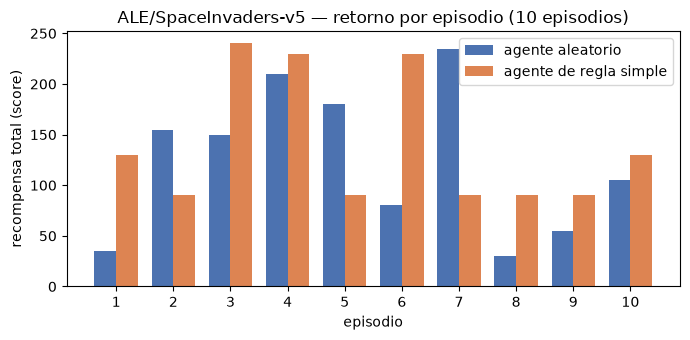

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(1, N_EP + 1); w = 0.38
ax.bar(x - w/2, [r for _, r in resultados["aleatorio"]], w,
       label="agente aleatorio", color="#4C72B0")
ax.bar(x + w/2, [r for _, r in resultados["regla simple"]], w,
       label="agente de regla simple", color="#DD8452")
ax.set_xlabel("episodio"); ax.set_ylabel("recompensa total (score)")
ax.set_title("ALE/SpaceInvaders-v5 — retorno por episodio (10 episodios)")
ax.set_xticks(x); ax.legend(); fig.tight_layout()
fig.savefig(FIGS / "spaceinvaders_random_vs_regla.png", dpi=150)
plt.show()

**La regla simple le gana al azar, pero por poco: 141.0 ± 62.4 contra 123.5 ± 69.5.** Un
~14% más de score. La dirección es la esperada —el agente aleatorio desperdicia 4 de cada 6
acciones sin disparar— pero con desviaciones estándar de ese tamaño y sólo 10 episodios, la
diferencia no es concluyente.

Hay un detalle que sí es claro: la regla **sobrevive menos** (406.7 pasos contra 461.0) y aun
así puntea más. Es decir, no juega mejor a la defensiva; simplemente dispara más por unidad
de tiempo.

Por qué la mejora no es mayor:

1. **Sticky actions.** Con `repeat_action_probability=0.25` una de cada cuatro acciones se
   ignora y se repite la anterior, así que el barrido "determinista" se degrada solo.
2. **La regla no mira la pantalla.** No esquiva balas ni apunta a nada: ignora por completo
   la observación, así que toda la ganancia viene de disparar más, no de jugar mejor. Por eso
   muere antes.
3. **Disparar siempre no es gratis.** En Space Invaders sólo puede haber un disparo del
   jugador en pantalla a la vez, así que pulsar `FIRE` en cada paso no sube la cadencia de
   tiro por encima de ese límite.

Esto es justamente lo que motiva el aprendizaje: para pasar de aquí, la política tiene que
ser **función de la observación**, y esa función es lo que ninguna regla escrita a mano
captura bien.

> **Dos detalles de reproducibilidad** que costaron números distintos en cada corrida hasta
> corregirlos, ambos resueltos dentro de `ejecutar_episodio`:
>
> - `env.reset(seed=...)` **no** siembra el RNG de `env.action_space`, así que
>   `agente_aleatorio` daba resultados distintos en cada ejecución. Hay que llamar
>   explícitamente a `env.action_space.seed(seed)`.
> - `agente_regla_simple` lleva un contador de pasos. Si no se reinicia por episodio, el
>   resultado depende de cuántas veces se llamó antes al agente (el mismo experimento daba
>   141 o 207 según si se habían grabado videos primero). `ejecutar_episodio` llama a
>   `funcion_agente.reset()` si el agente expone ese atributo.

## 4. Discusión

**Qué quedó funcionando.** Un módulo de cinco funciones que crea entornos de ALE, ejecuta
agentes arbitrarios y graba video vía `RecordVideo`, verificado con un self-check con
asserts (`python ale_utils.py`). El módulo es genérico: la misma llamada sirve para
`ALE/SpaceInvaders-v5` y para `CartPole-v1`.

**Qué falta para entrenar.** El siguiente paso no toca estas funciones: se envuelve el
entorno con `AtariPreprocessing` + `FrameStackObservation` dentro de `crear_entorno`, y
`funcion_agente` deja de ser una función pura para pasar a ser el `forward` de una CNN con
sus pesos. La firma `funcion_agente(observation, env) -> action` ya soporta eso sin cambios:
un agente entrenado es un *callable* con estado, no una función distinta.

**Por qué el agente aleatorio importa.** No es un relleno: es la línea base contra la que se
mide cualquier agente entrenado. Un retorno medio de ~124 puntos es el "cero" de este juego;
el DQN original reporta ~1 700. Sin esa referencia, un número suelto no significa nada.

**Limitaciones.** Diez episodios son pocos para estimar medias con esta varianza; la
literatura usa 100. Y todas las corridas usan semillas 0-9 con sticky actions activadas, así
que los números son reproducibles pero no independientes de la semilla del emulador.

## Reglas de tecnología

Las restricciones de este laboratorio (qué librerías y conceptos están permitidos y cuáles
no, con su justificación) están en [`CLAUDE.md`](CLAUDE.md) y se resumen en el reporte.
En una línea: **Gymnasium + ale-py, sin frameworks de RL y sin entrenar nada**.